<a href="https://colab.research.google.com/github/IGiovanniRamirez/Giovanni-Ramirez-Data-Portfolio/blob/main/mercadolibre-funnel-analysis/An%C3%A1lisis%20de%20Embudo%20y%20Retenci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Análisis de embudo y retención para MercadoLibre

**Rol:** Analista de Producto – Crecimiento y Retención  
**Periodo de análisis:** 01-ene-2025 a 31-ago-2025  

## 🎯 Objetivo
Analizar el embudo de conversión y la retención de usuarios para identificar:
- Etapas con mayor pérdida de usuarios
- Diferencias por país
- Comportamiento de retención por cohortes

## 🧰 Herramientas utilizadas
- SQL
- Análisis de cohortes
- Métricas de producto (conversión y retención)

## 📊 Contexto del negocio

El equipo de producto busca responder:

1. ¿En qué etapa del embudo se pierden más usuarios?
2. ¿Cómo varía la conversión por país?
3. ¿Qué tan bien retenemos a los usuarios a lo largo del tiempo?

Se analizaron dos tablas principales:
- `mercadolibre_funnel`: eventos del usuario
- `mercadolibre_retention`: actividad y retención

## 🔍 Exploración inicial de datos

SELECT *   
FROM mercadolibre_funnel          
LIMIT 5;

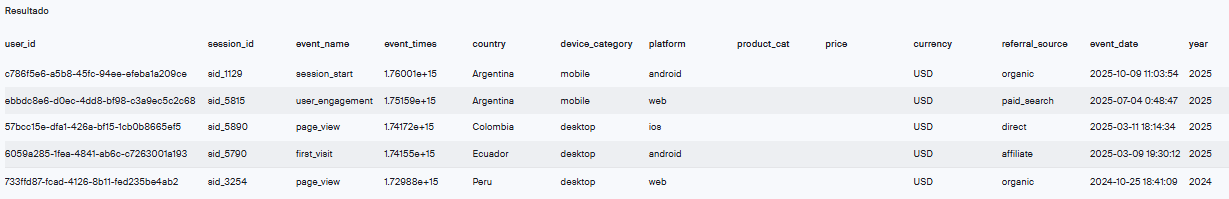

SELECT *      
FROM mercadolibre_retention      
LIMIT 5;

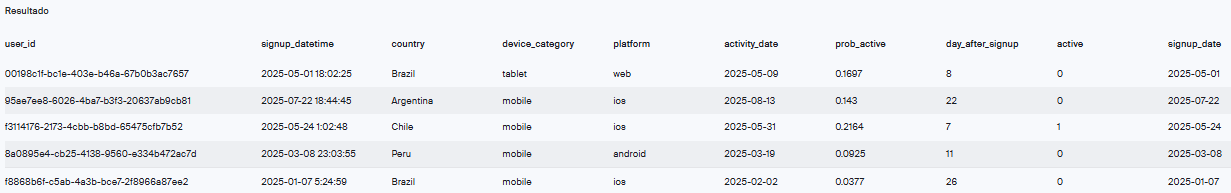

### 📌 Observaciones
- Se identifican eventos clave del funnel
- Se cuenta con información de país, fechas y actividad

## 🔄 Identificación de eventos del embudo

SELECT  DISTINCT event_name         
FROM mercadolibre_funnel        
ORDER BY event_name;

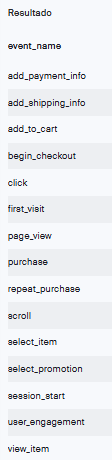

### 📌 Etapas del embudo
1. first_visit  
2. select_item / select_promotion  
3. add_to_cart  
4. begin_checkout  
5. add_shipping_info  
6. add_payment_info  
7. purchase  

## 🧱 Construcción del embudo de conversión

WITH first_visit AS(    
    SELECT DISTINCT user_id       
    FROM mercadolibre_funnel       
    WHERE event_name = 'first_visit'        
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'       
),    
select_item AS(       
    SELECT DISTINCT user_id        
    FROM mercadolibre_funnel       
    WHERE event_name IN ('select_item','select_promotion')      
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'      
),       
add_to_cart AS(        
    SELECT DISTINCT user_id         
    FROM mercadolibre_funnel        
    WHERE event_name = 'add_to_cart'         
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'        
),      
begin_checkout AS(       
    SELECT DISTINCT user_id            
    FROM mercadolibre_funnel      
    WHERE event_name = 'begin_checkout'         
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'      
),        
add_shipping_info AS(         
    SELECT DISTINCT user_id           
    FROM mercadolibre_funnel          
    WHERE event_name = 'add_shipping_info'         
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'       
),      
add_payment_info AS(        
    SELECT DISTINCT user_id          
    FROM mercadolibre_funnel        
    WHERE event_name = 'add_payment_info'        
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'         
),         
purchase AS(       
    SELECT DISTINCT user_id            
    FROM mercadolibre_funnel          
    WHERE event_name = 'purchase'         
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'        
)         
SELECT          
  COUNT(fv.user_id) AS usuarios_first_visit,          
  COUNT(si.user_id) AS usuarios_select_item,        
  COUNT(ac.user_id) AS usuarios_add_to_cart,        
  COUNT(bc.user_id) AS usuarios_begin_checkout,         
  COUNT(asi.user_id) AS usuarios_add_shipping_info,       
  COUNT(ap.user_id) AS usuarios_add_payment_info,       
  COUNT(p.user_id) AS usuarios_purchase        
FROM first_visit fv        
LEFT JOIN select_item si ON fv.user_id = si.user_id        
LEFT JOIN add_to_cart ac ON fv.user_id = ac.user_id         
LEFT JOIN begin_checkout bc ON fv.user_id = bc.user_id         
LEFT JOIN add_shipping_info asi ON fv.user_id = asi.user_id          
LEFT JOIN add_payment_info ap ON fv.user_id = ap.user_id         
LEFT JOIN purchase p ON fv.user_id = p.user_id;           

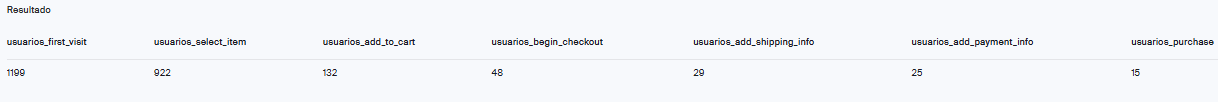

## 📉 Tasa de conversión por etapa

-- (Usa el mismo CTE anterior)     
SELECT             
ROUND(usuarios_select_item*100.0/NULLIF(usuarios_first_visit,0),2) AS conversion_select_item,       
ROUND(usuarios_add_to_cart*100.0/NULLIF(usuarios_first_visit,0),2) AS conversion_add_to_cart,          
ROUND(usuarios_begin_checkout*100.0/NULLIF(usuarios_first_visit,0),2) AS conversion_begin_checkout,           
ROUND(usuarios_add_shipping_info*100.0/NULLIF(usuarios_first_visit,0),2) AS conversion_add_shipping_info,          
ROUND(usuarios_add_payment_info*100.0/NULLIF(usuarios_first_visit,0),2) AS conversion_add_payment_info,           
ROUND(usuarios_purchase*100.0/NULLIF(usuarios_first_visit,0),2) AS conversion_purchase          
FROM funnel_counts;

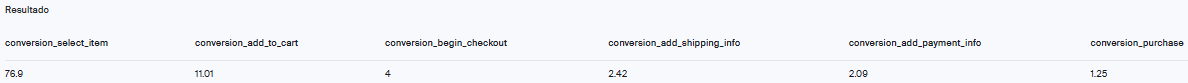

### 📌 Insight clave
La mayor caída ocurre entre **select_item → add_to_cart**.

## 🌎 Embudo segmentado por país

WITH first_visits AS (       
  SELECT DISTINCT user_id,           
     country           
  FROM mercadolibre_funnel         
  WHERE event_name = 'first_visit'          
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'         
),         
select_item AS (         
  SELECT DISTINCT user_id,         
     country          
  FROM mercadolibre_funnel         
  WHERE event_name IN ('select_item', 'select_promotion')          
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'          
),          
add_to_cart AS (         
  SELECT DISTINCT user_id,       
     country      
  FROM mercadolibre_funnel         
  WHERE event_name = 'add_to_cart'        
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'     
),     
begin_checkout AS (       
  SELECT DISTINCT user_id,     
     country     
  FROM mercadolibre_funnel        
  WHERE event_name = 'begin_checkout'       
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'     
),      
add_shipping_info AS (         
  SELECT DISTINCT user_id,      
     country        
  FROM mercadolibre_funnel       
  WHERE event_name = 'add_shipping_info'       
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'     
),    
add_payment_info AS (    
  SELECT DISTINCT user_id,        
     country     
  FROM mercadolibre_funnel      
  WHERE event_name = 'add_payment_info'     
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'        
),     
purchase AS (      
  SELECT DISTINCT user_id,        
     country      
  FROM mercadolibre_funnel       
  WHERE event_name = 'purchase'          
    AND event_date BETWEEN '2025-01-01' AND '2025-08-31'       
),      
funnel_counts AS(        
SELECT         
    fv.country,         
  COUNT(fv.user_id) AS usuarios_first_visit,       
  COUNT(si.user_id) AS usuarios_select_item,       
  COUNT(a.user_id) AS usuarios_add_to_cart,       
  COUNT(bc.user_id) AS usuarios_begin_checkout,       
  COUNT(asi.user_id) AS usuarios_add_shipping_info,     
  COUNT(api.user_id) AS usuarios_add_payment_info,      
  COUNT(p.user_id) AS usuarios_purchase        
FROM first_visits fv           
LEFT JOIN select_item si        ON fv.user_id = si.user_id AND fv.country = si.country          
LEFT JOIN add_to_cart a         ON fv.user_id = a.user_id AND fv.country = a.country       
LEFT JOIN begin_checkout bc     ON fv.user_id = bc.user_id AND fv.country = bc.country        
LEFT JOIN add_shipping_info asi ON fv.user_id = asi.user_id AND fv.country = asi.country        
LEFT JOIN add_payment_info api  ON fv.user_id = api.user_id AND fv.country = api.country     
LEFT JOIN purchase p            ON fv.user_id = p.user_id AND fv.country = p.country         
GROUP BY fv.country         
)      
SELECT        
country,         
usuarios_select_item*100.0/NULLIF(usuarios_first_visit,0) AS conversion_select_item,       
usuarios_add_to_cart*100.0/NULLIF(usuarios_first_visit,0) AS conversion_add_to_cart,      
usuarios_begin_checkout*100.0/NULLIF(usuarios_first_visit,0) AS conversion_begin_checkout,       
usuarios_add_shipping_info*100.0/NULLIF(usuarios_first_visit,0) AS conversion_add_shipping_info,        
usuarios_add_payment_info*100.0/NULLIF(usuarios_first_visit,0) AS conversion_add_payment_info,       
usuarios_purchase*100.0/NULLIF(usuarios_first_visit,0) AS conversion_purchase      
FROM funnel_counts        
ORDER BY conversion_purchase DESC;        

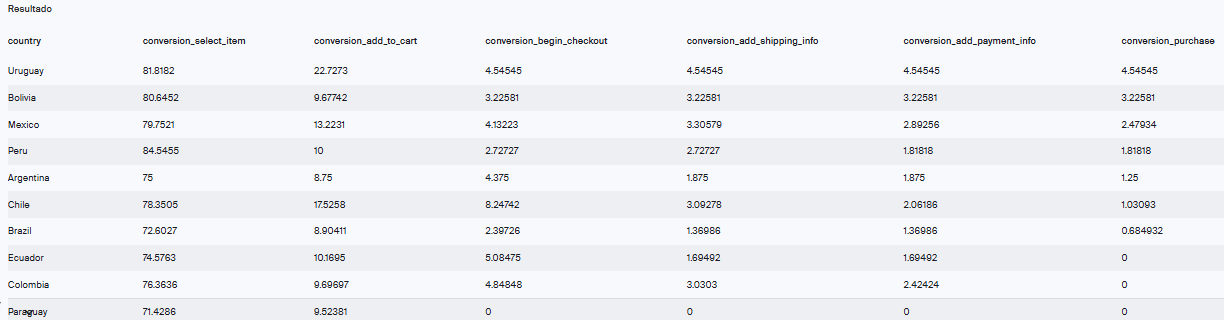

### 📌 Insight
- Perú presenta mayor caída en el primer paso
- Uruguay menor pérdida en el primer paso

## 🔁 Retención de usuarios por país

SELECT      
  country,         
  COUNT (DISTINCT CASE WHEN day_after_signup >=7 AND active=1 THEN user_id END) AS users_d7,          
  COUNT (DISTINCT CASE WHEN day_after_signup >=14 AND active=1 THEN user_id END) AS users_d14,        
  COUNT (DISTINCT CASE WHEN day_after_signup >=21 AND active=1 THEN user_id END) AS users_d21,       
  COUNT (DISTINCT CASE WHEN day_after_signup >=28 AND active=1 THEN user_id END) AS users_d28        
FROM mercadolibre_retention         
WHERE activity_date BETWEEN '2025-01-01' AND '2025-08-31'       
GROUP BY country;      

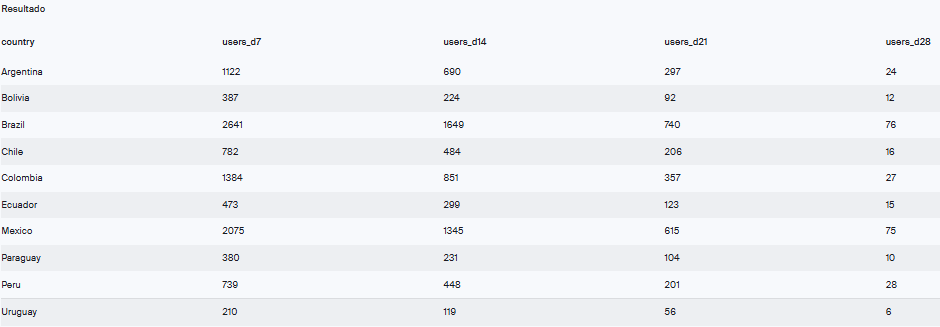

## 📊 Retención (%) por país

SELECT         
  country,          
  ROUND((COUNT(DISTINCT CASE WHEN day_after_signup >= 7 AND active = 1 THEN user_id END))*100.0 / NULLIF(COUNT(DISTINCT user_id),0),1) AS retention_d7_pct,        
  ROUND((COUNT(DISTINCT CASE WHEN day_after_signup >= 14 AND active = 1 THEN user_id END))*100.0 / NULLIF(COUNT(DISTINCT user_id),0),1) AS retention_d14_pct,        
  ROUND((COUNT(DISTINCT CASE WHEN day_after_signup >= 21 AND active = 1 THEN user_id END))*100.0 / NULLIF(COUNT(DISTINCT user_id),0),1) AS retention_d21_pct,          
  ROUND((COUNT(DISTINCT CASE WHEN day_after_signup >= 28 AND active = 1 THEN user_id END))*100.0 / NULLIF(COUNT(DISTINCT user_id),0),1) AS retention_d28_pct          
FROM mercadolibre_retention           
GROUP BY country;     

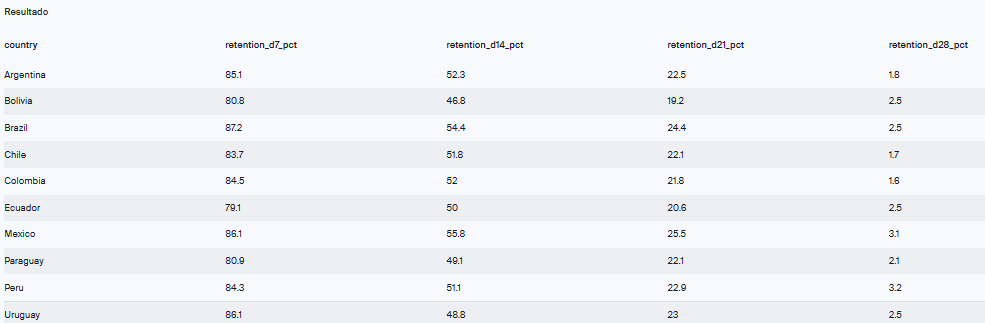

## 🧩 Análisis de cohortes

SELECT         
user_id,        
    MIN(signup_date::date) AS signup_date,            
TO_CHAR(DATE_TRUNC('month', MIN(signup_date::date)), 'YYYY-MM') AS cohort      
FROM mercadolibre_retention     
GROUP BY user_id          
LIMIT 5;    

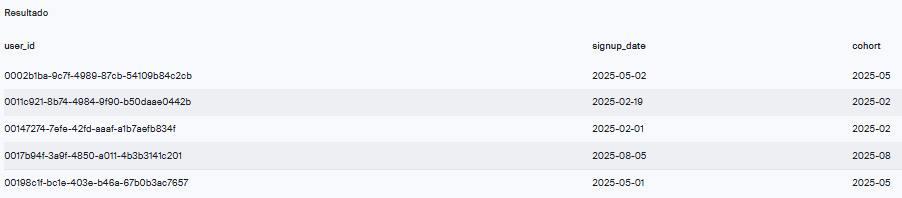


WITH cohort AS (         
SELECT          
user_id,          
TO_CHAR(DATE_TRUNC('month', MIN(signup_date)), 'YYYY-MM') AS cohort         
FROM mercadolibre_retention         
GROUP BY user_id        
),        
activity AS (        
SELECT           
mr.user_id,         
c.cohort,           
mr.day_after_signup,        
mr.active          
FROM mercadolibre_retention mr         
LEFT JOIN cohort c ON mr.user_id=c.user_id         
)         
SELECT            
cohort,        
ROUND((COUNT(DISTINCT CASE WHEN day_after_signup >= 7 AND active = 1 THEN user_id END))*100.0 / NULLIF(COUNT(DISTINCT user_id),0),1) AS retention_d7_pct,        
ROUND((COUNT(DISTINCT CASE WHEN day_after_signup >= 14 AND active = 1 THEN user_id END))*100.0 / NULLIF(COUNT(DISTINCT user_id),0),1) AS retention_d14_pct,          
ROUND((COUNT(DISTINCT CASE WHEN day_after_signup >= 21 AND active = 1 THEN user_id END))*100.0 / NULLIF(COUNT(DISTINCT user_id),0),1) AS retention_d21_pct,          
ROUND((COUNT(DISTINCT CASE WHEN day_after_signup >= 28 AND active = 1 THEN user_id END))*100.0 / NULLIF(COUNT(DISTINCT user_id),0),1) AS retention_d28_pct           
FROM activity           
GROUP BY cohort             
ORDER BY cohort;           

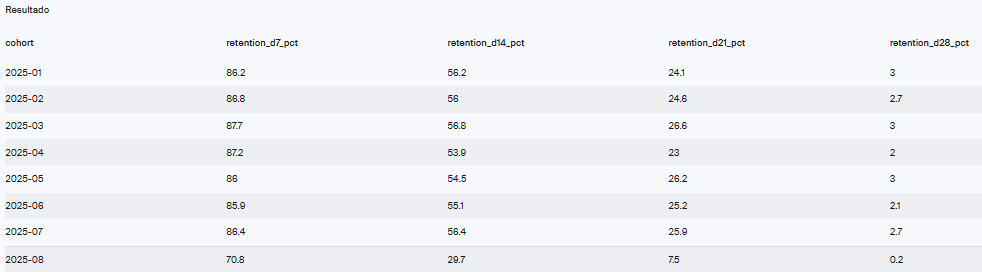

## 📌 Conclusiones

### 🔎 Hallazgos
- Mayor caída: select_item → add_to_cart
- País crítico: Perú
- Mejor retención: México y Perú
- Peor retención: Colombia

### 🚀 Recomendaciones
- Optimizar página de producto
- Reducir fricción en checkout
- Incentivos y recompensas para retención

## 💭 Reflexión personal

### ¿Qué etapa mejoraría primero?
La transición de selección a carrito.

### ¿Qué aprendí?
- Los usuarios abandonan en etapas de decisión
- La retención cae rápidamente sin incentivos

## 📌 Informe ejecutivo (C → F → I)

<img width="962" height="292" alt="image" src="https://github.com/user-attachments/assets/cf4f71b5-48b4-4d76-92f2-aec00dea7462" />
<img width="464" height="225" alt="image" src="https://github.com/user-attachments/assets/70dfd2cc-d5b6-464d-9866-400beae52303" />